This notebook will have a training and a testing section.
All a data being used shall be from 1st January 2020 - 31st August 2026. \
I will impose a ~80-20 test/train split. \
The training period shall run from 1st January 2020 - 30th June 2025. \
The testing period shall run frm 1st July 2025 - 31st August 2026.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

In [50]:
TEST_START = "2020-01-01"
TEST_END = "2025-06-30"

In [51]:
ticker_universe = ["BTC-USD", "ETH-USD", "BNB-USD", "XRP-USD", "SOL-USD", "TRX-USD", "ZEC-USD", "DOGE-USD", "XMR-USD", "LINK-USD", "ADA-USD", "XLM-USD", "BCH-USD", "LTC-USD", "NEAR-USD", "AVAX-USD", "HBAR-USD", "SHIB-USD", "KCS-USD", "ALGO-USD", "DASH-USD"]

In [52]:
daily_prices = yf.download(tickers=ticker_universe, period="max", interval="1d")

[*********************100%***********************]  21 of 21 completed


In [53]:
daily_returns = (daily_prices["Close"] / daily_prices["Close"].shift() - 1).loc[TEST_START:TEST_END]
daily_volumes = daily_prices["Volume"].loc[TEST_START:TEST_END]

In [531]:
def momentumSignal(daily_returns, daily_volumes):
    return daily_returns.shift().rolling(window=14).mean() / daily_returns.shift().rolling(window=45).std()

LTC-USD    -0.035274
XMR-USD    -0.029303
TRX-USD    -0.023383
LINK-USD   -0.021352
BCH-USD    -0.015102
DASH-USD   -0.012689
ZEC-USD    -0.006152
SHIB-USD    0.005652
ETH-USD     0.005816
BTC-USD     0.029703
NEAR-USD    0.030941
HBAR-USD    0.031436
XLM-USD     0.032330
ALGO-USD    0.032668
DOGE-USD    0.042871
SOL-USD     0.044571
ADA-USD     0.047509
BNB-USD     0.047719
XRP-USD     0.053135
KCS-USD     0.054688
AVAX-USD    0.079601
dtype: float64

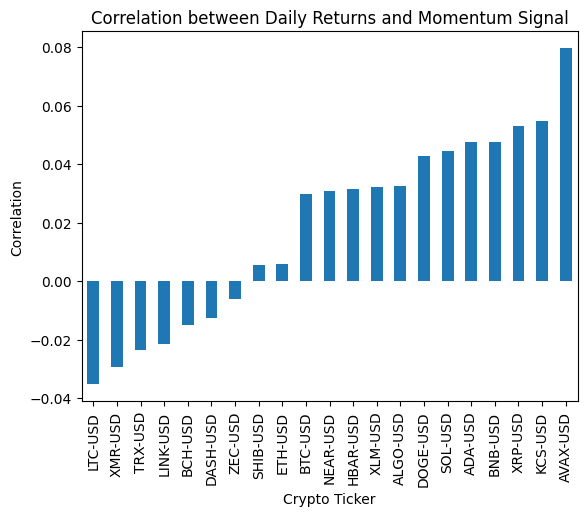

In [532]:
signal_correlations = pd.Series({
    ticker: daily_returns[ticker].corr(momentumSignal(daily_returns[ticker], daily_volumes[ticker])) for ticker in ticker_universe
})
signal_correlations.sort_values().plot(kind="bar", title="Correlation between Daily Returns and Momentum Signal", xlabel="Crypto Ticker", ylabel="Correlation")
signal_correlations.sort_values()

In [533]:
ticker_filter = signal_correlations[signal_correlations > 0.02].index.tolist()
ticker_filter

['BTC-USD',
 'BNB-USD',
 'XRP-USD',
 'SOL-USD',
 'DOGE-USD',
 'ADA-USD',
 'XLM-USD',
 'NEAR-USD',
 'AVAX-USD',
 'HBAR-USD',
 'KCS-USD',
 'ALGO-USD']

In [534]:
def sharpeRatio(x):
    return x.mean() / x.std() * np.sqrt(252)

In [535]:
def momentumWeights(daily_returns, daily_volumes):
    signal = momentumSignal(daily_returns, daily_volumes)
    ranked = signal.rank(axis=1)
    demeaned = ranked.sub(ranked.mean(axis=1), axis=0)
    weights = demeaned.div(demeaned.abs().sum(axis=1), axis=0)
    lagged_weights = weights.iloc[::2].reindex(weights.index, method="ffill")
    return lagged_weights

In [536]:
def grossMomentum(daily_returns, daily_volumes):
    return (momentumWeights(daily_returns, daily_volumes) * daily_returns).sum(axis=1)

In [537]:
def turnOver(weights):
    return (weights - weights.shift()).abs().sum(axis=1)

In [538]:
def netMomentum(daily_returns, daily_volumes):
    gross_momentum = grossMomentum(daily_returns, daily_volumes)
    turnover = turnOver(momentumWeights(daily_returns, daily_volumes))
    net_momentum = gross_momentum.subtract(turnover * 0.002, fill_value=0)
    return net_momentum

In [539]:
momentum_returns = netMomentum(daily_returns[ticker_filter], daily_volumes[ticker_filter])

In [540]:
f"Sharpe Ratio: {sharpeRatio(momentum_returns):.2f}"

'Sharpe Ratio: 0.88'

Date
2020Q1    0.26
2020Q2    3.09
2020Q3    2.59
2020Q4    2.96
2021Q1    0.04
2021Q2    3.64
2021Q3    1.60
2021Q4    0.98
2022Q1    0.22
2022Q2    0.91
2022Q3   -0.23
2022Q4    2.20
2023Q1    1.18
2023Q2   -3.20
2023Q3   -0.48
2023Q4    1.53
2024Q1   -1.13
2024Q2   -0.85
2024Q3   -2.21
2024Q4    4.70
2025Q1   -1.13
2025Q2   -2.44
Freq: Q-DEC, dtype: float64

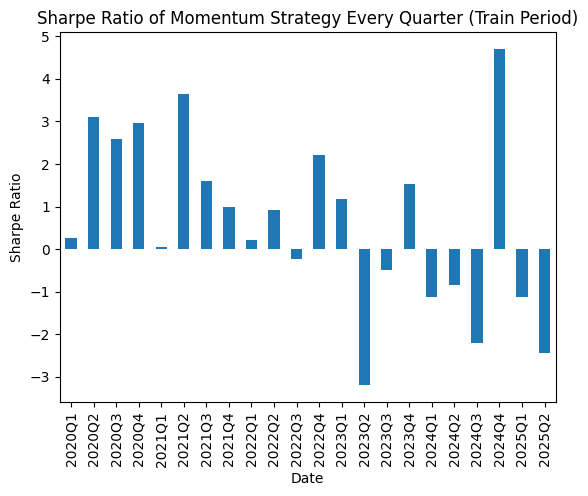

In [541]:
quarterly_sharpes = momentum_returns.resample("QE").apply(sharpeRatio).to_period("Q")
quarterly_sharpes.plot(kind="bar", title="Sharpe Ratio of Momentum Strategy Every Quarter (Train Period)", ylabel="Sharpe Ratio")
quarterly_sharpes.round(2)

'Max Drawdown: 48%'

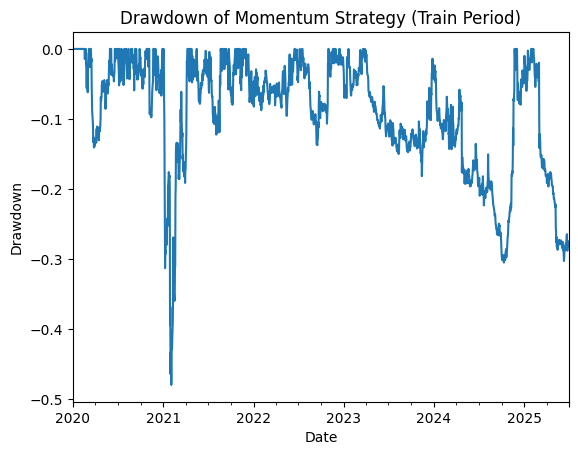

In [542]:
momentum_drawdown = (1 + momentum_returns).cumprod() / (1 + momentum_returns).cumprod().cummax() - 1
momentum_drawdown.plot(
    ylabel="Drawdown", title="Drawdown of Momentum Strategy (Train Period)"
)
f"Max Drawdown: {-momentum_drawdown.min():.0%}"